<a href="https://colab.research.google.com/github/goelshreya3001-droid/Academic-Project/blob/main/loan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

In [ ]:
import os

os.listdir("/content")

['.config', 'bank_loan_default_10k.xls', '.ipynb_checkpoints', 'sample_data']

In [ ]:
df = pd.read_csv("/content/bank_loan_default_10k.xls")

In [ ]:
df.head()

,customer_id,age,gender,marital_status,education,employment_type,years_employed,annual_income,monthly_expenses,credit_score,...,credit_card_utilization,num_late_payments,previous_defaults,savings_balance,bank_balance,employment_stability,loan_purpose,residence_type,dependents,default
0,CUST000001,29,Male,Married,Graduate,Self-Employed,7.0,661000,37200,671,...,39.4,0,0,869500,55300,Unstable,Home,Family,1,1
1,CUST000002,39,Male,Married,Graduate,Salaried,14.8,1309000,84000,827,...,11.9,0,0,72000,83900,Stable,Business,Rented,2,0
2,CUST000003,21,Female,Married,High School,Self-Employed,2.4,173000,10500,759,...,0.0,0,0,26500,24500,Moderate,Education,Family,1,0
3,CUST000004,51,Male,Married,Graduate,Salaried,22.5,1359000,65100,766,...,29.5,1,0,712500,762200,Stable,Car,Owned,1,0
4,CUST000005,43,Female,Married,High School,Self-Employed,25.0,929000,61400,715,...,29.1,1,0,137500,49200,Stable,Home,Rented,2,0


In [ ]:
df.shape

(10000, 27)

In [ ]:
df.columns

Index(['customer_id', 'age', 'gender', 'marital_status', 'education',
       'employment_type', 'years_employed', 'annual_income',
       'monthly_expenses', 'credit_score', 'existing_loans',
       'total_loan_amount', 'loan_amount', 'loan_term_months', 'interest_rate',
       'debt_to_income_ratio', 'num_credit_cards', 'credit_card_utilization',
       'num_late_payments', 'previous_defaults', 'savings_balance',
       'bank_balance', 'employment_stability', 'loan_purpose',
       'residence_type', 'dependents', 'default'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              10000 non-null  object 
 1   age                      10000 non-null  int64  
 2   gender                   10000 non-null  object 
 3   marital_status           10000 non-null  object 
 4   education                10000 non-null  object 
 5   employment_type          10000 non-null  object 
 6   years_employed           10000 non-null  float64
 7   annual_income            10000 non-null  int64  
 8   monthly_expenses         10000 non-null  int64  
 9   credit_score             10000 non-null  int64  
 10  existing_loans           10000 non-null  int64  
 11  total_loan_amount        10000 non-null  int64  
 12  loan_amount              10000 non-null  int64  
 13  loan_term_months         10000 non-null  int64  
 14  interest_rate          

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,10000.0,37.219000,9.569692e+00,21.000,30.000,37.000,44.00,7.000000e+01
years_employed,10000.0,10.640810,9.460396e+00,0.000,2.200,9.000,17.00,5.200000e+01
annual_income,10000.0,902744.000000,9.222802e+05,60000.000,382000.000,680000.000,1133000.00,1.247200e+07
monthly_expenses,10000.0,53437.050000,4.885543e+04,5000.000,24475.000,42200.000,68600.00,6.402000e+05
credit_score,10000.0,740.155800,5.737112e+01,331.000,711.000,747.000,779.00,9.000000e+02
existing_loans,10000.0,1.017600,1.029755e+00,0.000,0.000,1.000,2.00,6.000000e+00
total_loan_amount,10000.0,381312.500000,8.013148e+05,0.000,0.000,114000.000,418000.00,1.947600e+07
loan_amount,10000.0,916515.500000,1.475034e+06,25000.000,125000.000,380000.000,1071250.00,1.500000e+07
loan_term_months,10000.0,87.835200,7.844855e+01,12.000,36.000,60.000,120.00,3.000000e+02
interest_rate,10000.0,11.243962,2.333964e+00,7.000,9.200,11.260,13.08,2.086000e+01


In [ ]:
df.isnull().sum()

,0
customer_id,0
age,0
gender,0
marital_status,0
education,0
employment_type,0
years_employed,0
annual_income,0
monthly_expenses,0
credit_score,0


In [ ]:
df.duplicated().sum()


np.int64(0)

Find target column


In [ ]:
print("Columns:")
print(df.columns.tolist())

print("\nShape:")
print(df.shape)

print("\nFirst 5 rows:")
display(df.head())


Columns:
['customer_id', 'age', 'gender', 'marital_status', 'education', 'employment_type', 'years_employed', 'annual_income', 'monthly_expenses', 'credit_score', 'existing_loans', 'total_loan_amount', 'loan_amount', 'loan_term_months', 'interest_rate', 'debt_to_income_ratio', 'num_credit_cards', 'credit_card_utilization', 'num_late_payments', 'previous_defaults', 'savings_balance', 'bank_balance', 'employment_stability', 'loan_purpose', 'residence_type', 'dependents', 'default']

Shape:
(10000, 27)

First 5 rows:


,customer_id,age,gender,marital_status,education,employment_type,years_employed,annual_income,monthly_expenses,credit_score,...,credit_card_utilization,num_late_payments,previous_defaults,savings_balance,bank_balance,employment_stability,loan_purpose,residence_type,dependents,default
0,CUST000001,29,Male,Married,Graduate,Self-Employed,7.0,661000,37200,671,...,39.4,0,0,869500,55300,Unstable,Home,Family,1,1
1,CUST000002,39,Male,Married,Graduate,Salaried,14.8,1309000,84000,827,...,11.9,0,0,72000,83900,Stable,Business,Rented,2,0
2,CUST000003,21,Female,Married,High School,Self-Employed,2.4,173000,10500,759,...,0.0,0,0,26500,24500,Moderate,Education,Family,1,0
3,CUST000004,51,Male,Married,Graduate,Salaried,22.5,1359000,65100,766,...,29.5,1,0,712500,762200,Stable,Car,Owned,1,0
4,CUST000005,43,Female,Married,High School,Self-Employed,25.0,929000,61400,715,...,29.1,1,0,137500,49200,Stable,Home,Rented,2,0


In [ ]:
df["default"].value_counts()

,count
default,
0,8623
1,1377


In [ ]:
df["default"].value_counts(normalize=True) * 100

,proportion
default,
0,86.23
1,13.77


EDA

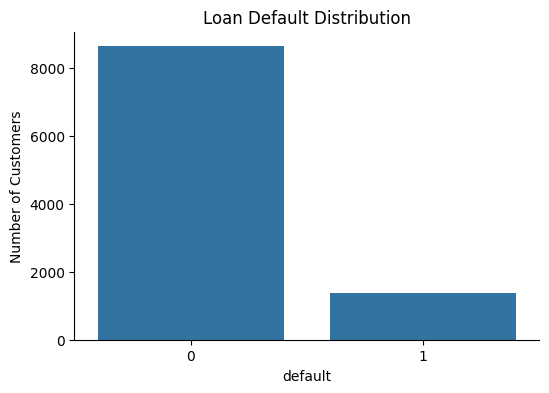

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x="default", data=df)

plt.title("Loan Default Distribution")
plt.xlabel("default")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns

print(numeric_cols)

Index(['age', 'years_employed', 'annual_income', 'monthly_expenses',
       'credit_score', 'existing_loans', 'total_loan_amount', 'loan_amount',
       'loan_term_months', 'interest_rate', 'debt_to_income_ratio',
       'num_credit_cards', 'credit_card_utilization', 'num_late_payments',
       'previous_defaults', 'savings_balance', 'bank_balance', 'dependents',
       'default'],
      dtype='object')


In [ ]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,10000.0,37.219000,9.569692e+00,21.000,30.000,37.000,44.00,7.000000e+01
years_employed,10000.0,10.640810,9.460396e+00,0.000,2.200,9.000,17.00,5.200000e+01
annual_income,10000.0,902744.000000,9.222802e+05,60000.000,382000.000,680000.000,1133000.00,1.247200e+07
monthly_expenses,10000.0,53437.050000,4.885543e+04,5000.000,24475.000,42200.000,68600.00,6.402000e+05
credit_score,10000.0,740.155800,5.737112e+01,331.000,711.000,747.000,779.00,9.000000e+02
existing_loans,10000.0,1.017600,1.029755e+00,0.000,0.000,1.000,2.00,6.000000e+00
total_loan_amount,10000.0,381312.500000,8.013148e+05,0.000,0.000,114000.000,418000.00,1.947600e+07
loan_amount,10000.0,916515.500000,1.475034e+06,25000.000,125000.000,380000.000,1071250.00,1.500000e+07
loan_term_months,10000.0,87.835200,7.844855e+01,12.000,36.000,60.000,120.00,3.000000e+02
interest_rate,10000.0,11.243962,2.333964e+00,7.000,9.200,11.260,13.08,2.086000e+01


In [ ]:
categorical_cols = df.select_dtypes(include="object").columns

print(categorical_cols)

Index(['customer_id', 'gender', 'marital_status', 'education',
       'employment_type', 'employment_stability', 'loan_purpose',
       'residence_type'],
      dtype='object')


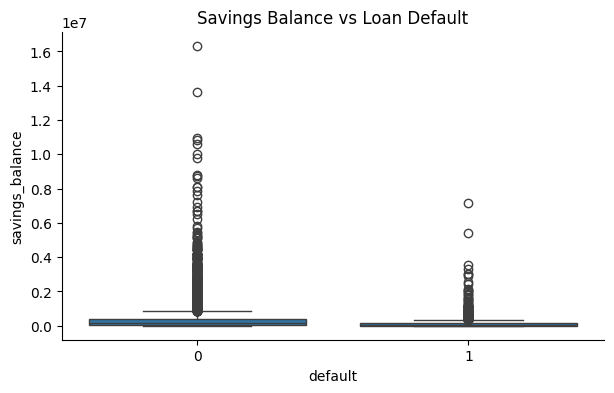

In [ ]:
plt.figure(figsize=(7,4))

sns.boxplot(x="default", y="savings_balance", data=df)

plt.title("Savings Balance vs Loan Default")
plt.show()

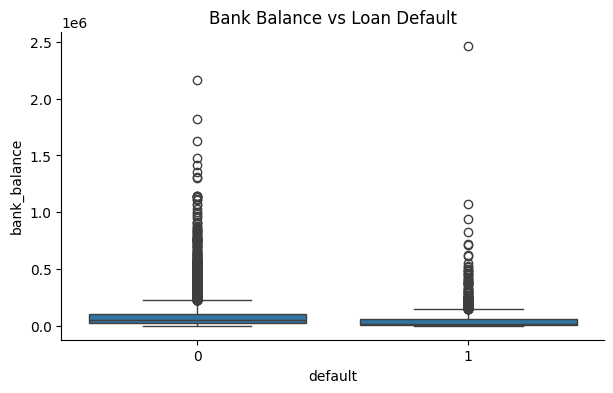

In [ ]:
plt.figure(figsize=(7,4))

sns.boxplot(x="default", y="bank_balance", data=df)

plt.title("Bank Balance vs Loan Default")
plt.show()

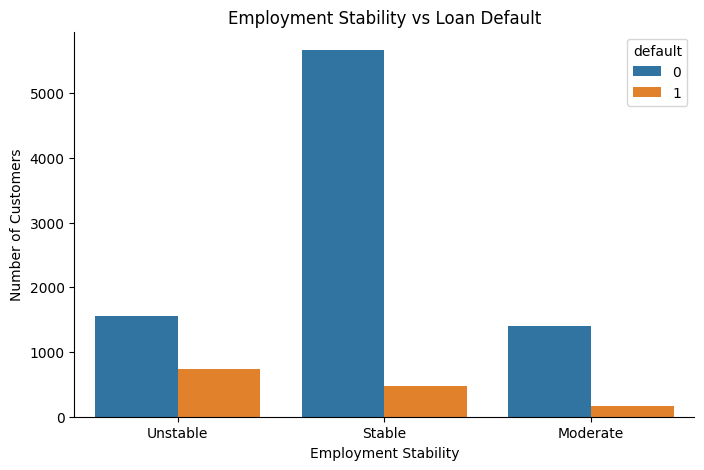

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="employment_stability",
    hue="default",
    data=df
)

plt.title("Employment Stability vs Loan Default")
plt.xlabel("Employment Stability")
plt.ylabel("Number of Customers")

plt.show()

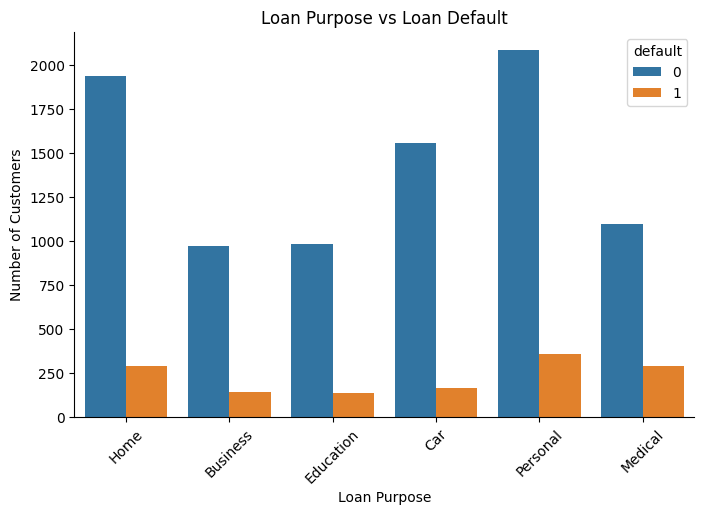

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="loan_purpose",
    hue="default",
    data=df
)

plt.title("Loan Purpose vs Loan Default")
plt.xlabel("Loan Purpose")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.show()

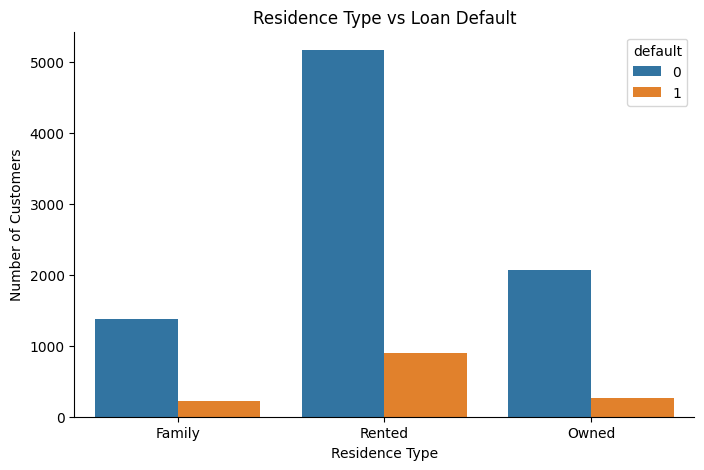

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="residence_type",
    hue="default",
    data=df
)

plt.title("Residence Type vs Loan Default")
plt.xlabel("Residence Type")
plt.ylabel("Number of Customers")

plt.show()

Feature Engineering


In [ ]:
X = df.drop("default", axis=1)
y = df["default"]

In [ ]:
print("Features:", X.shape)
print("Target:", y.shape)

Features: (10000, 26)
Target: (10000,)


In [ ]:
categorical_cols = X.select_dtypes(include="object").columns

print("Categorical columns:")
print(categorical_cols)

Categorical columns:
Index(['customer_id', 'gender', 'marital_status', 'education',
       'employment_type', 'employment_stability', 'loan_purpose',
       'residence_type'],
      dtype='object')


In [ ]:
numeric_cols = X.select_dtypes(include=np.number).columns

print("Numerical columns:")
print(numeric_cols)

Numerical columns:
Index(['age', 'years_employed', 'annual_income', 'monthly_expenses',
       'credit_score', 'existing_loans', 'total_loan_amount', 'loan_amount',
       'loan_term_months', 'interest_rate', 'debt_to_income_ratio',
       'num_credit_cards', 'credit_card_utilization', 'num_late_payments',
       'previous_defaults', 'savings_balance', 'bank_balance', 'dependents'],
      dtype='object')


In [ ]:
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

In [ ]:
X.head()

,age,years_employed,annual_income,monthly_expenses,credit_score,existing_loans,total_loan_amount,loan_amount,loan_term_months,interest_rate,...,employment_type_Unemployed,employment_stability_Stable,employment_stability_Unstable,loan_purpose_Car,loan_purpose_Education,loan_purpose_Home,loan_purpose_Medical,loan_purpose_Personal,residence_type_Owned,residence_type_Rented
0,29,7.0,661000,37200,671,1,79000,2260000,120,10.18,...,False,False,True,False,False,True,False,False,False,False
1,39,14.8,1309000,84000,827,1,844000,1175000,60,11.14,...,False,True,False,False,False,False,False,False,False,True
2,21,2.4,173000,10500,759,2,244000,145000,60,9.58,...,False,False,False,False,True,False,False,False,False,False
3,51,22.5,1359000,65100,766,2,1185000,595000,48,9.36,...,False,True,False,True,False,False,False,False,True,False
4,43,25.0,929000,61400,715,1,267000,1450000,180,9.33,...,False,True,False,False,False,True,False,False,False,True


In [ ]:
X.shape

(10000, 10035)

In [ ]:
X.dtypes

,0
age,int64
years_employed,float64
annual_income,int64
monthly_expenses,int64
credit_score,int64
...,...
loan_purpose_Home,bool
loan_purpose_Medical,bool
loan_purpose_Personal,bool
residence_type_Owned,bool


train-test split


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8000, 10035)
X_test: (2000, 10035)
y_train: (8000,)
y_test: (2000,)


Feature scaling


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred_log = log_model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_log = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", accuracy_log)

Logistic Regression Accuracy: 0.8905


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94      1725
           1       0.89      0.23      0.37       275

    accuracy                           0.89      2000
   macro avg       0.89      0.61      0.65      2000
weighted avg       0.89      0.89      0.86      2000



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_log)

print(cm)

[[1717    8]
 [ 211   64]]


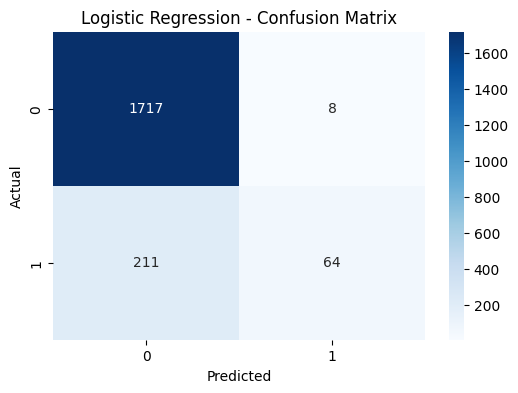

In [ ]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")

plt.show()